# **Домашнее задание №1**

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from itertools import *

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:

df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1884,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
1885,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


##Постановка задачи
  Подготовить для самостоятельно выбранного набора данных анализ различных гипотез, оформеленный, как в виде написанного кода, так и в виде отчёта с аналитической человекопонятной частью.

# Расшифровка параметров таблицы
---
*   age - возраст пациента(Numeric)
*   sex - Пол пациента. Значения: 1 = мужчина, 0 = женщина
*   cp - Тип боли в груди. Значения: 0 = Типичная стенокардия, 1 = Атипичная стенокардия, 2 = Боль, не связанная со стенокардией, 3 = Бессимптомно
*   trestbps - Кровяное давление в состоянии покоя (в мм рт. ст.)
*   chol - Уровень холестерина в сыворотке крови (в мг/дл)
*   fbs - Уровень сахара в крови натощак > 120 мг/дл. Значения: 1 = верно, 0 = неверно
*   restecg - Результаты электрокардиографии в покое. Значения: 0 = В норме, 1 = аномалия зубца ST-T, 2 = Гипертрофия левого желудочка.
*   thalach - Достигнутая максимальная частота сердечных сокращений
*   exang - Стенокардия, вызванная физической нагрузкой. Значения: 1 = да, 0 = нет
*   oldpeak - Изменения ST, вызванная физической нагрузкой, по сравнению с отдыхом
*   slope - Наклон верхней части сегмента ST упражнения. Значения: 0 = Наклон вверх, 1 = Ровный, 2 = Наклон вниз.
*   ca - Количество крупных сосудов (0-3), окрашенных при рентгеноскопии. Значения: 0, 1, 2, 3
*   thal - Типы талассемии. Значения: 1 = Нормальная, 2 = Фиксированный дефект, 3 = Обратимый дефект.
*   target - Переменная исхода (риск сердечного приступа). Значения: 1 = большая вероятность сердечного приступа, 0 = меньшая вероятность сердечного приступа.

















In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.279131,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.280877,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


# Анализ данных, приведённых в таблице



Обратим внимание на ряд числовых показателей:


*   age
*   chol
*   trestbps
*   thalachh
*   oldpeak

Ранее данные названия уже были расшифрованы нами, поэтому сразу перейдем к теоретической справке, которая поможет точнее понимать суть показателей.

**Холестерин** (chol в параметрах) — это жироподобное вещество, которое играет важную роль в работе организма. Участвует в построении оболочки клеток, выработке гормонов (например, тестостерона и эстрогена), производстве желчи и переваривании жиров.

**Сегмент ST** — отрезок электрокардиограммы (ЭКГ) между концом комплекса QRS и началом зубца Т.




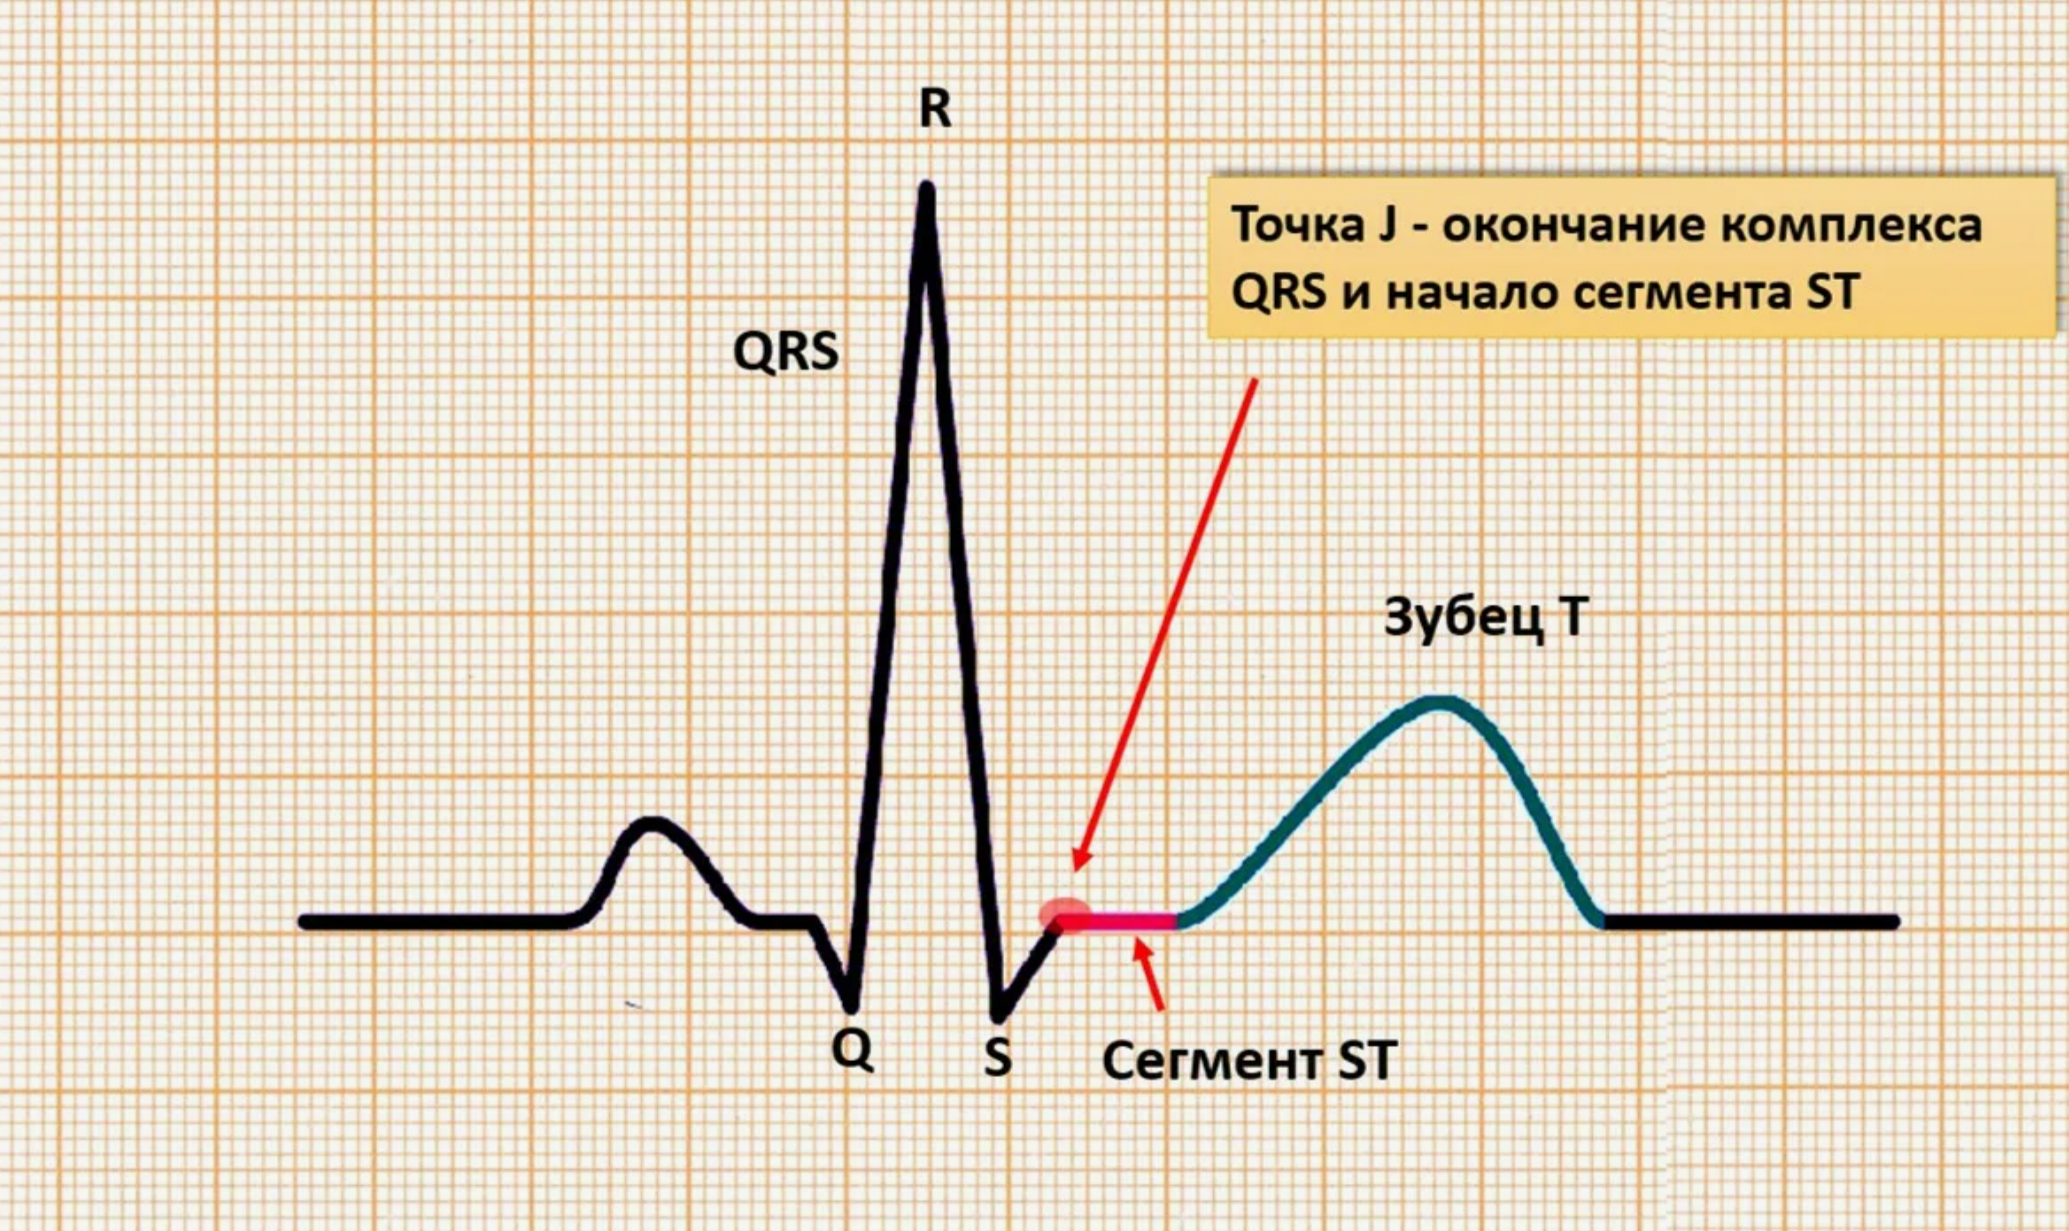

Заметим, что во всех столбцах нет пропусков(1888 из 1888 строчек полностью заполнены), поэтому дополнительной предобработки не требуется.


# Анализ показателя age

---
1) Среднее значение: 54.4 года

2) Медиана: 55 лет

3) Стандартное отклонение: 9.08 лет

4) Диапазон: 29-77 лет

5) квантили: 25% - 48 лет, 50% - 55 лет, 75% - 61 год



---
Среднее (54.4) и медиана (55) практически совпадают, что указывает, предположительно, на нормальное или близкое к нормальному распределение возраста в выборке.

Стандартное отклонение 9.08 лет показывает умеренный разброс возрастов вокруг среднего.

Возрастные группы по клиническим данным:


25% пациентов моложе 48 лет

50% пациентов в возрасте 48-61 года

25% пациентов старше 61 года



Согласно данным, можно предположить, что типичный возрастной диапазон для сердечно-сосудистых заболеваний 48-61 год. Но все же присутствуют выбросы, которые могут быть вызваны возникновением заболевания в более молодом возрасте.




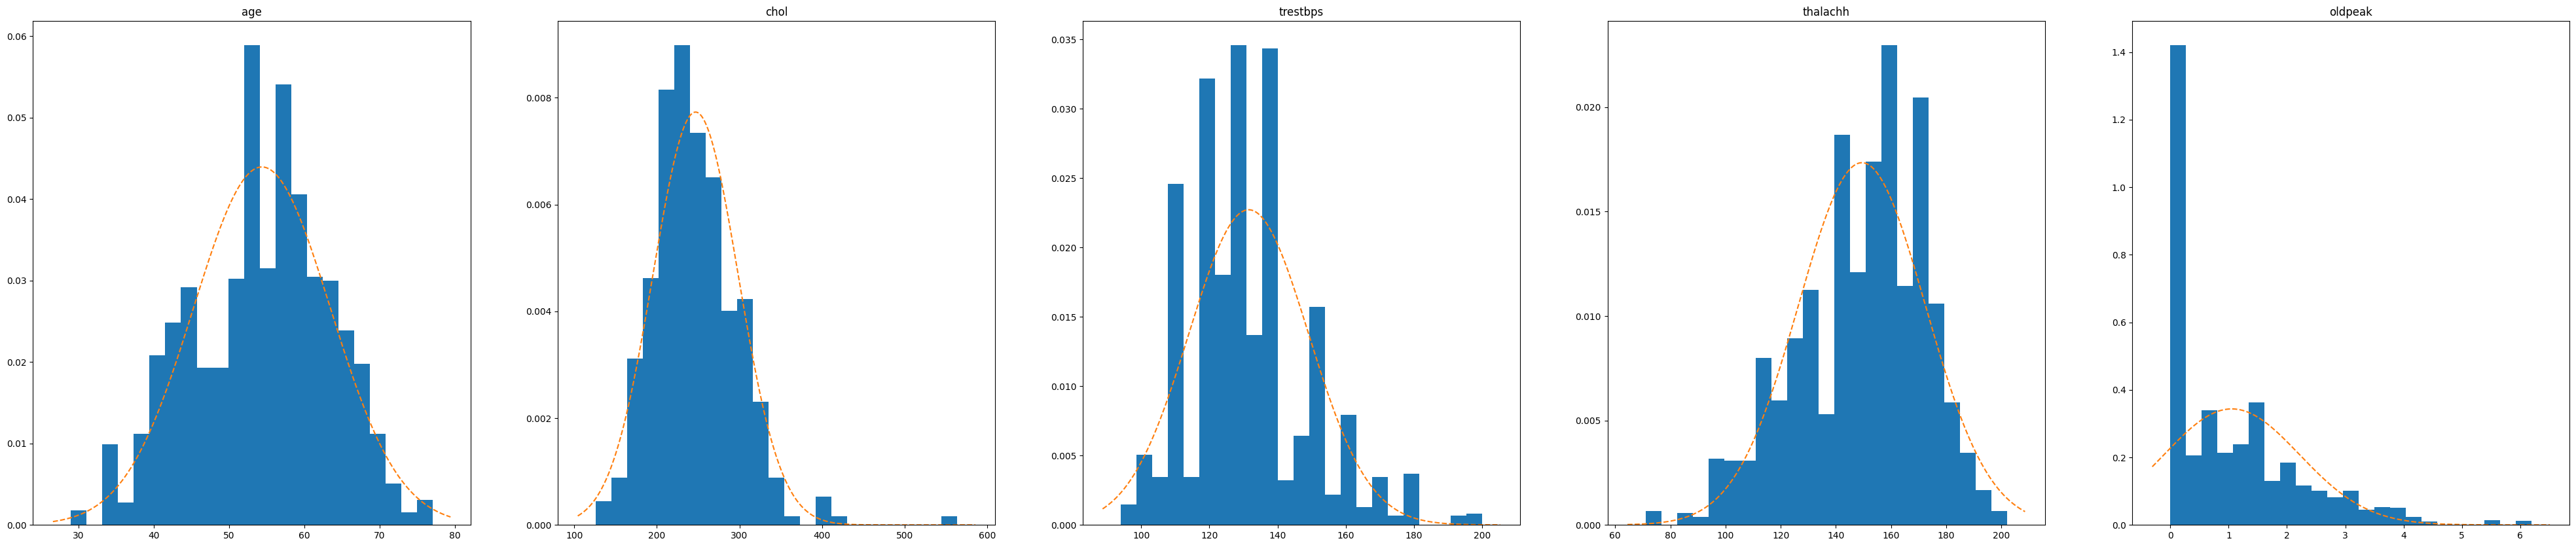

In [ ]:
keys = ['age', 'chol', 'trestbps', 'thalachh','oldpeak']

fig, axes = plt.subplots(ncols=len(keys))
fig.set_size_inches(10 * len(keys), 10)
axes = axes.flatten()

for key, ax in zip(keys, axes):
    ax.hist(df[key], density=True, bins=23)

    loc = df[key].mean()
    scale = df[key].std()

    x_left, x_right = ax.get_xlim()
    x = np.linspace(x_left, x_right, 10000)
    y = stats.norm.pdf(x, loc=loc, scale=scale)

    ax.plot(x, y, linestyle='dashed')
    ax.set_title(key)

# Анализ показателя chol

---
1) Среднее значение: 246.86 мг/дл

2) Медиана: 241 мг/дл

3) Стандартное отклонение: 51.61 мг/дл

4) Диапазон: 126-564 мг/дл

5) квантили: 25% - 211 мг/дл, 50% - 241 мг/дл, 75% - 276 мг/дл



---
Медиана (241) меньше среднего (246.86), что указывает на правостороннюю асимметрию - наличие пациентов с очень высоким уровнем холестерина.

Выбросы: Максимальное значение 564 мг/дл значительно превышает 75% квантиль (276), что подтверждает наличие выраженных выбросов.

Клиническая интерпретация:

Норма: <200 мг/дл (только 25% пациентов ниже 211)

Пограничный высокий: 200-239 мг/дл (значительная часть выборки)

Высокий: ≥240 мг/дл (медиана и выше)

Вывод: Большинство пациентов имеют повышенный уровень холестерина, что соответствует профилю риска сердечно-сосудистых заболеваний.

# Анализ показателя trestbps

---

1) Среднее значение: 131.55 мм рт.ст.

2) Медиана: 130 мм рт.ст.

3) Стандартное отклонение: 17.56 мм рт.ст.

4) Диапазон: 94-200 мм рт.ст.

5) квантили: 25% - 120 мм рт.ст., 50% - 130 мм рт.ст., 75% - 140 мм рт.ст.


---
Среднее и медиана практически равны, распределение близко к нормальному.

Разброс: Умеренный разброс значений вокруг среднего.

Клинические категории:

1) Нормальное: <120 мм рт.ст. (25% пациентов)

2) Предгипертензия: 120-139 мм рт.ст. (50% пациентов между Q1 и Q3)

3) Гипертензия 1 стадии: 140-159 мм рт.ст.

4) Гипертензия 2 стадии: ≥160 мм рт.ст.

Вывод: Преобладают пациенты с предгипертензией и гипертензией, что ожидаемо для кардиологической выборки.

# Анализ показателя thalachh

---

1) Среднее значение: 149.42 уд/мин

2) Медиана: 152 уд/мин

3) Стандартное отклонение: 23.01 уд/мин

4) Диапазон: 71-202 уд/мин

5) квантили: 25% - 133 уд/мин, 50% - 152 уд/мин, 75% - 166 уд/мин


---
Левосторонняя асимметрия: Медиана (152) выше среднего (149.42), что указывает на сдвиг в сторону более высоких значений.

Широкий разброс: Стандартное отклонение 23 уд/мин показывает значительную вариабельность максимальной ЧСС.

Физиологический контекст:

1) Нижние 25% пациентов имеют ЧСС ниже 133 уд/мин

2) Верхние 25% - выше 166 уд/мин

Вывод: Разброс может отражать разные уровни физической подготовки, медикаментозной терапии или тяжести состояния.

# Анализ показателя oldpeak

---

1) Среднее значение: 1.05 мм

2) Медиана: 0.8 мм

3) Стандартное отклонение: 1.16 мм

4) Диапазон: 0-6.2 мм

5) квантили: 25% - 0 мм, 50% - 0.8 мм, 75% - 1.6 мм


---
Сильная правосторонняя асимметрия: Медиана (0.8) значительно меньше среднего (1.05), что указывает на наличие пациентов с выраженной депрессией ST.

Наличие нулевых значений: 25% пациентов имеют нулевую депрессию ST.

Выбросы: Максимальное значение 6.2 мм значительно превышает 75% квантиль (1.6 мм).

Клиническая значимость:

1) 0-1 мм: незначительная депрессия (50% пациентов)

2) 1-2 мм: умеренная депрессия

3) 2 мм: выраженная депрессия (вероятно, пациенты с выбросами)

# Квантили
Построим Q-Q кривую. Это график, который показывает соответствие между теоретическим значением квантиля на выборке и его реальным значением.

Чем ближке график к графику $y = x$, тем более нормальным является распределение значений выборки.



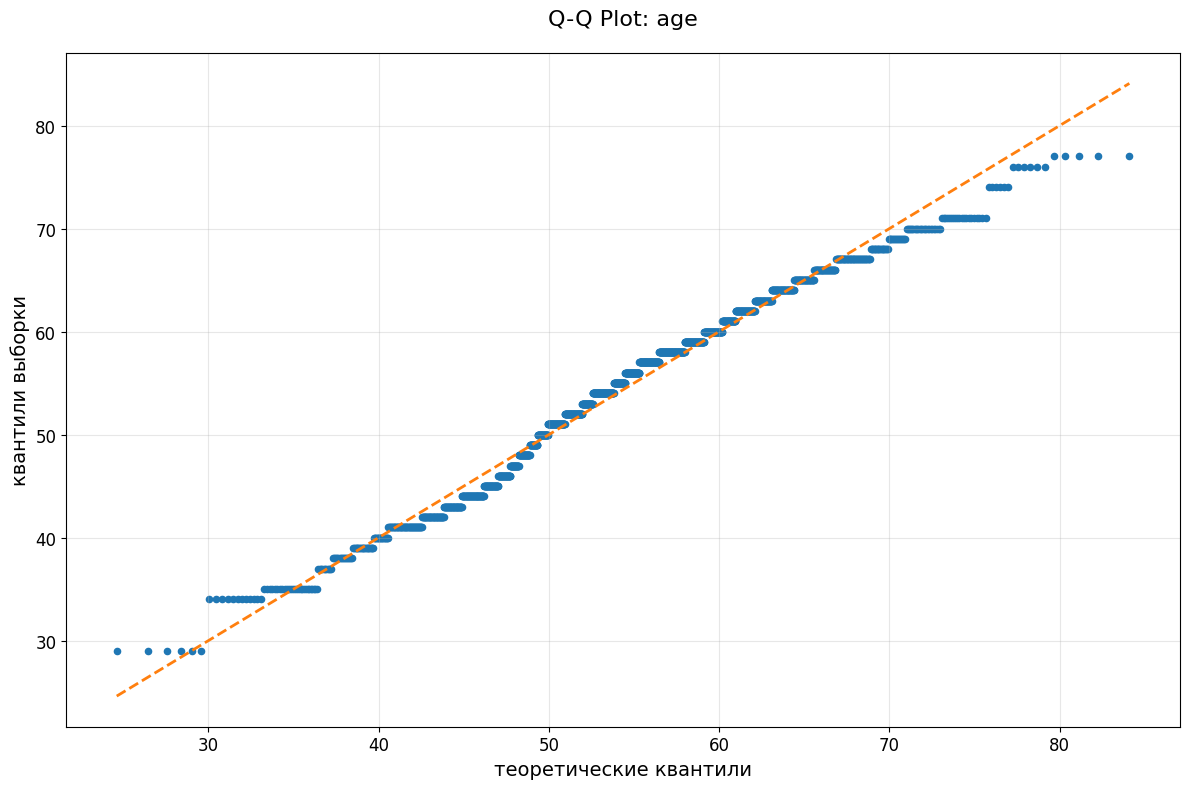

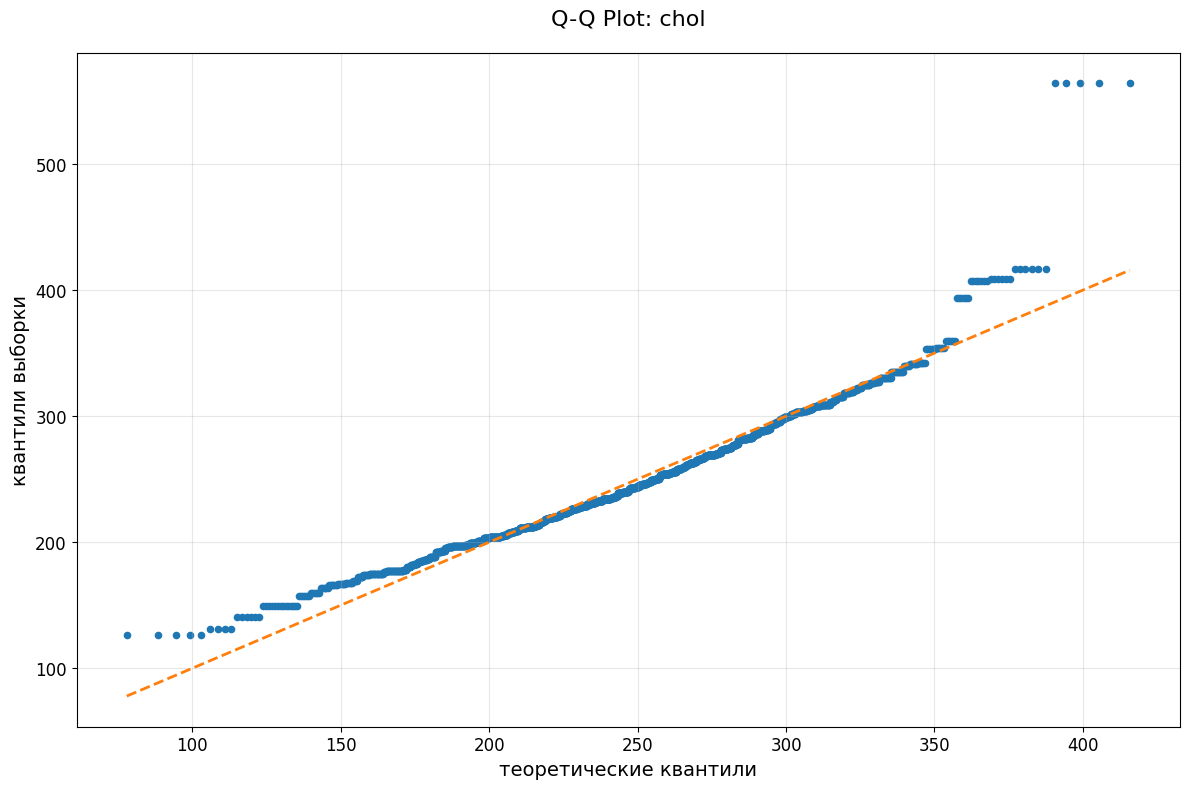

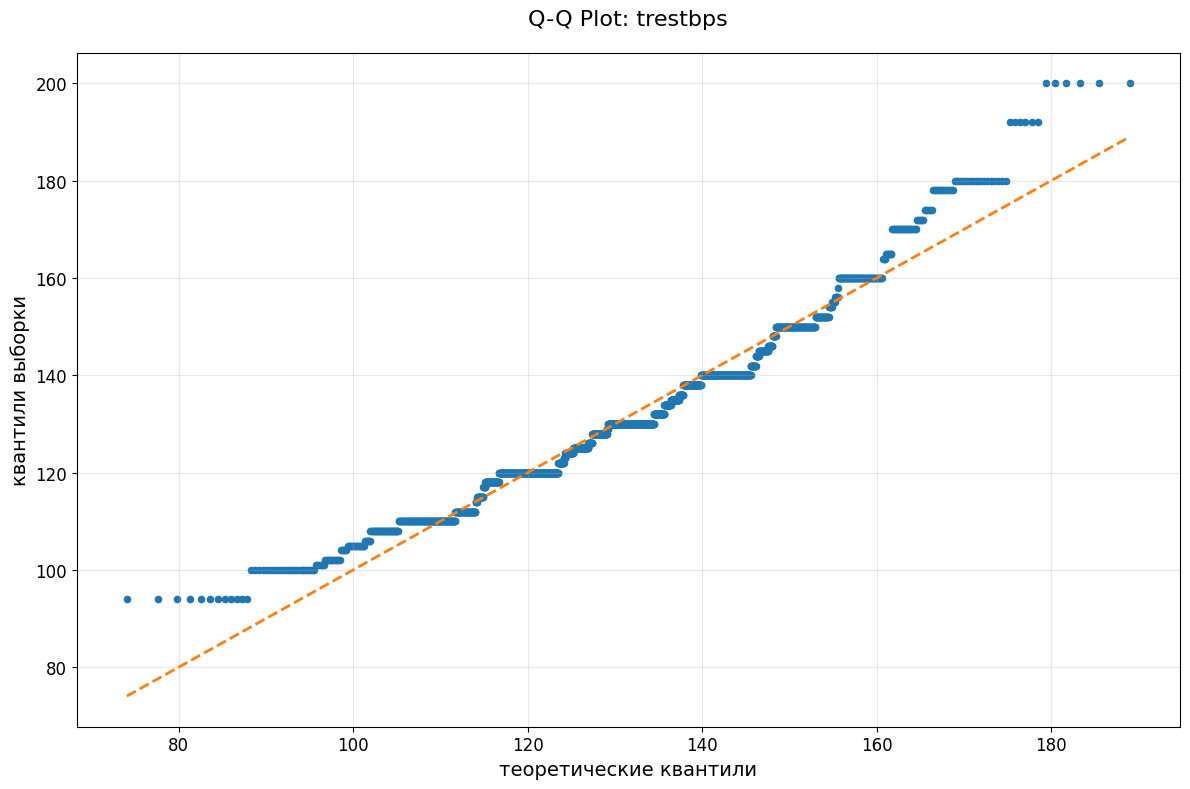

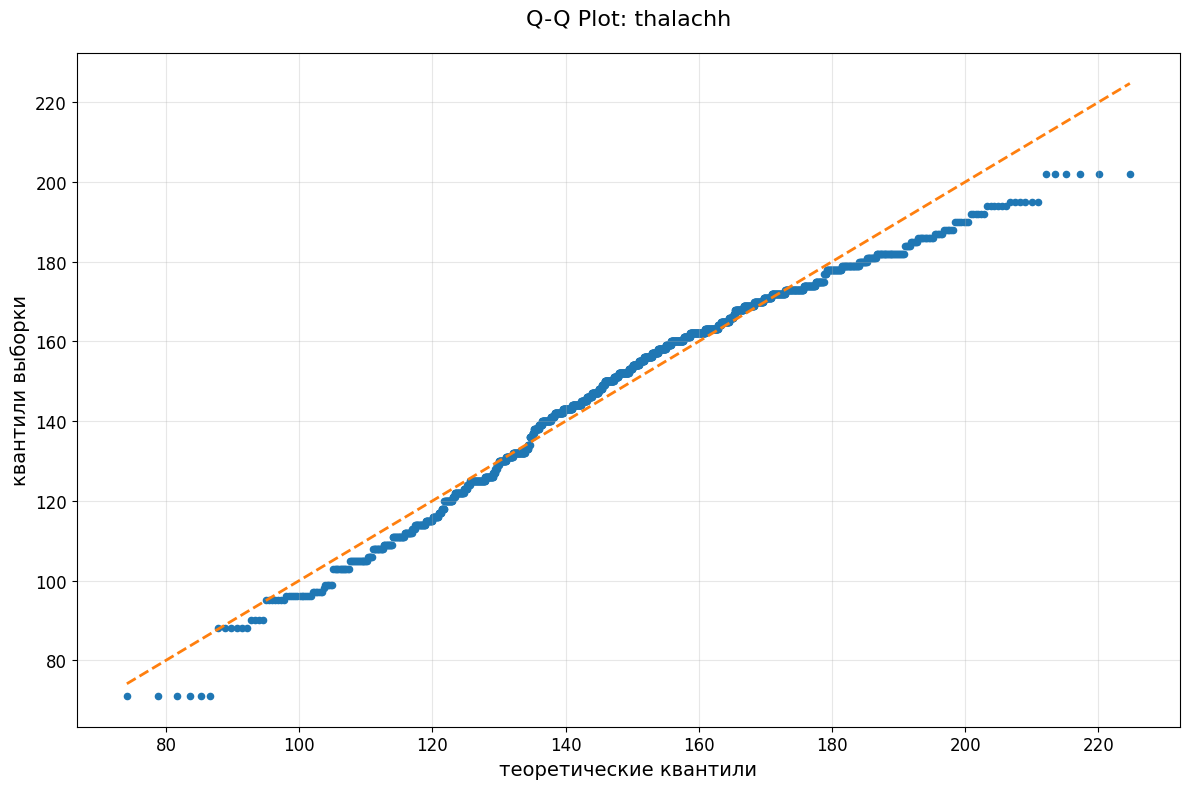

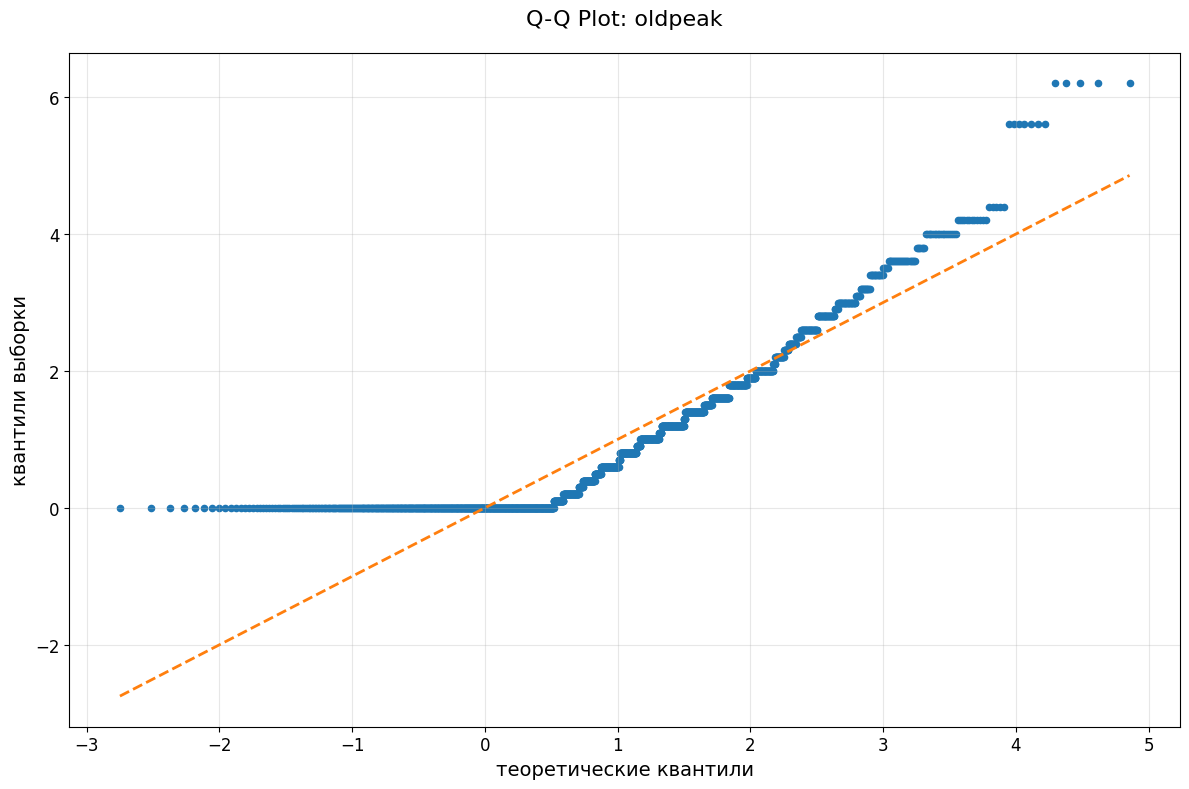

In [ ]:

fig.set_size_inches(12 * len(keys), 8)
axes = axes.flatten()

for key in keys:
    # Создаем новую фигуру для каждого параметра
    fig, ax = plt.subplots(figsize=(12, 8))

    samples = df[key]
    loc = samples.mean()
    scale = samples.std()

    interval = np.linspace(0, 1, samples.shape[0])[1:-1]
    x = stats.norm.ppf(interval, loc=loc, scale=scale)
    y = np.quantile(samples, interval)

    # Строим график
    ax.scatter(x, y, s=20)
    ax.plot(x, x, color='C1', linestyle='dashed', linewidth=2)

    # Настраиваем оформление
    ax.set_title(f'Q-Q Plot: {key}', fontsize=16, pad=20)
    ax.set_xlabel('теоретические квантили', fontsize=14)
    ax.set_ylabel('квантили выборки', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Заметим, что наиболее выраженное отклонение от нормального распределения наблюдается у параметров chol и oldpeak, что требует специальных преобразований перед статистическим анализом и построением моделей.

# Статистические показатели выборок
Оценим нормальность выборок также на основании известных характеристик нормального распределения. В частности:

Вероятность попасть в интервал:
1) от $\mu - \sigma$ до $\mu + \sigma$ равна $0.68$,

2) в интервал от $\mu - 2\sigma$ до $\mu + 2\sigma$ равна $0.95$,

3)  в интервал от $\mu - 3\sigma$ до $\mu + 3\sigma$ равна $0.997$.

Если рассчётные цифры оказываются близки к теоретическим, то распределения можно признать нормальными.

На основании такой оценки Width сильно ближе к нормально распределению, чем Price и Year, что достаточно логично. Дешевых и новых автомобилей больше.

Тот факт, что распределения данных значений явлются нормальными или близкими к ним позволяет использовать другие методы для анализа взаимосвязей в данных.

In [ ]:
for key in keys:
    print(key)

    samples = df[key]

    loc = samples.mean()
    scale = samples.std()

    for i in range(1, 4):
        true_value = stats.norm.cdf(i) - stats.norm.cdf(-i)
        sample_value = ((samples >= loc - i * scale) & (samples <= loc + i * scale)).sum() / samples.shape[0]

        print(f'{i} sigma(s)')
        print(f'\ttheoretical:\t{true_value}')
        print(f'\tsample:\t\t{sample_value}')

    print()

age
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.621822033898305
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9661016949152542
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		1.0

chol
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.7261652542372882
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.965042372881356
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.9867584745762712

trestbps
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.6726694915254238
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9502118644067796
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.993114406779661

thalachh
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.6583686440677966
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.961864406779661
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.996292372881356

oldpeak
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.8490466101694916
2 sigma(s)
	theoretical:	0.95449

1. trestbps (артериальное давление)

* 1 сигма: 67.3% vs 68.3% (разница: -1.0%)

* 2 сигмы: 95.0% vs 95.4% (разница: -0.4%)

* 3 сигмы: 99.3% vs 99.7% (разница: -0.4%)

Заключение: Практически идеальное соответствие теоретическому нормальному распределению
В эпидемиологических исследованиях действительно часто наблюдается нормальное или близкое к нормальному распределение артериального давления в больших популяциях, особенно после исключения крайних значений. Нормальное распределение trestbps отражает фундаментальные биологические принципы гомеостаза и многокомпонентной регуляции этого критически важного физиологического параметра в относительно однородной кардиологической популяции

2. thalachh (максимальная ЧСС)
* 1 сигма: 65.8% vs 68.3% (разница: -2.5%)

* 2 сигмы: 96.2% vs 95.4% (разница: +0.8%)

* 3 сигмы: 99.6% vs 99.7% (разница: -0.1%)

Заключение: Очень хорошее соответствие, особенно для 2 и 3 сигм

3. age (возраст)
* 1 сигма: 62.2% vs 68.3% (разница: -6.1%)

* 2 сигмы: 96.6% vs 95.4% (разница: +1.2%)

* 3 сигмы: 100% vs 99.7% (разница: +0.3%)

Заключение: Умеренное отклонение в 1 сигме, но хорошее в 2-3 сигмах

4. chol (холестерин)
* 1 сигма: 72.6% vs 68.3% (разница: +4.3%)

* 2 сигмы: 96.5% vs 95.4% (разница: +1.1%)

* 3 сигмы: 98.7% vs 99.7% (разница: -1.0%)

Заключение: Заметное отклонение в 1 сигме (правосторонняя асимметрия)

5. oldpeak (депрессия ST)
* 1 сигма: 84.9% vs 68.3% (разница: +16.6%)

* 2 сигмы: 94.4% vs 95.4% (разница: -1.0%)

* 3 сигмы: 99.3% vs 99.7% (разница: -0.4%)

Заключение: Сильное отклонение от нормальности в 1 сигме

# Есть ли регрессия между параметрами $age$ и $trestbps$?

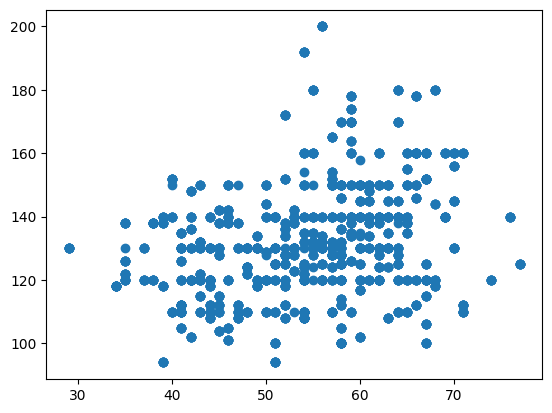

In [ ]:
plt.scatter(df['age'], df['trestbps'])
plt.show()


На графике тяжело с ходу понять, есть ли какие-то явные зависимости. Визулально может показаться, что есть, но нужно проверить.

# Рассчет регресии и проверка значимости


In [ ]:
def sum_of_squares(samples: np.ndarray) -> float:
    return ((samples - samples.mean()) ** 2).sum()
def squares(samples: np.ndarray) -> float:
    return ((samples ) ** 2).sum()

In [ ]:
ones = np.ones((len(df['age']),1))
x_pot = np.hstack((ones, df['age'].values.reshape(len(df['age']),1)))

XTX = x_pot.T.dot(x_pot)
XTX_inv = np.linalg.inv(XTX)

b = XTX_inv.dot(x_pot.T).dot(df['trestbps'])
z = x_pot.dot(b)
e = df['trestbps'] - z


In [ ]:
R = 1 - sum_of_squares(e) / sum_of_squares(np.array(df['trestbps']))
print(R)

0.07377036452956387


# Теоретическое обоснование анализа линейной регрессии

## 1. Математическая модель
Исследуется линейная зависимость между переменными:
- **Зависимая переменная (Y)**: кровяное давление в состоянии покоя (trestbps)
- **Независимая переменная (X)**: возраст пациентов (age)

Модель линейной регрессии:
y_i = β_0 + β_1 × x_i + ε_i

где:
- β_0 - свободный член (intercept)
- β_1 - коэффициент наклона (slope)
- ε_i - случайная ошибка

## 2. Матричная форма метода наименьших квадратов
Код реализует матричное решение МНК:

**Конструкция матрицы признаков:**
```python
x_bot = np.hstack((ones, df['age'].values.reshape(...)))
```
Создается матрица плана X, где первый столбец - единицы (для свободного члена), второй - значения возраста.

**Оценка коэффициентов:**
β_hat = (XᵀX)⁻¹XᵀY

В коде:
```python
XTX = x_bot.T.dot(x_bot)
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv.dot(x_bot.T).dot(df['trestbps'])
```

## 3. Вычисление прогнозов и остатков
**Прогнозируемые значения:**
ŷ = Xβ_hat
```python
z = x_bot.dot(b)
```

**Вектор остатков:**
e = y - ŷ
```python
e = df['trestbps'] - z
```

## 4. Оценка качества модели
**Коэффициент детерминации R²:**
R² = 1 - SS_res/SS_tot

где:
- SS_res = Σ(y_i - ŷ_i)² - сумма квадратов остатков
- SS_tot = Σ(y_i - ȳ)² - общая сумма квадратов

В коде:
```python
def sum_of_squares(samples: np.ndarray) -> float:
    return ((samples - samples.mean()) ** 2).sum()

R = 1 - sum_of_squares(e) / sum_of_squares(np.array(df['trestbps']))
```

## 5. Интерпретация результата
Полученное значение R² = 0.074 означает, что:
- **Только 7.4%** вариации кровяного давления объясняется возрастом пациентов
- **92.6%** вариации обусловлено другими факторами

**Статистический вывод:** Поскольку коэффициент детерминации близок к нулю, можно сделать вывод об **отсутствии существенной линейной зависимости** между возрастом и кровяным давлением в состоянии покоя в данной выборке.

## 6. Дополнительные соображения
Для полного анализа следует проверить:
- Статистическую значимость коэффициентов регрессии (t-тест)
- Условия применимости модели (нормальность остатков, гомоскедастичность)
- Возможность нелинейной зависимости между переменными
- Влияние выбросов на результаты регрессии

## 7. Практическая значимость
Полученный результат позволяет исключить возраст как основной фактор, влияющий на кровяное давление в состоянии покоя, и сосредоточить дальнейшие исследования на других потенциальных предикторах.


Исходя из полученных данных можно утверждать, что между кровяным давлением в состоянии покоя(trestbps) и возрастом пациентов(age) явных зависимостей нет.

# Статистический  тест
Построим статистический тест с нулевой гипотезой о том, что зависимости между возрастом и кровяным давлением.

Проведя рассчеты получаем, что F > t. Следовательно зависимость как таковая - есть.

In [ ]:
n = len(df)
m = 1

k1 = m
k2 = n - m - 1

k1, k2

(1, 1886)

In [ ]:
alpha = 0.05

t = stats.f.ppf(1 - alpha, k1, k2)
print(t)

3.8463941278136535


In [ ]:
F = (R / k1) / ((1 - R) / k2)
print(F)

150.212109583486


# F-тест значимости регрессии

##  Контекст анализа
Проверяется наличие **линейной зависимости** между:
- **Независимая переменная**: возраст
- **Зависимая переменная**: кровяное давление

##  Формулировка гипотез
- **Нулевая гипотеза (H₀)**: Нет линейной зависимости между возрастом и кровяным давлением
- **Альтернативная гипотеза (H₁)**: Существует линейная зависимость между возрастом и кровяным давлением

##  Параметры теста
- **Уровень значимости**: α = 0.05 — это стандартный и общепринятый подход для подобных задач
- **Число наблюдений**: n = 1888
- **Число независимых переменных**: m = 1
- **Степени свободы**:
  - k₁ = m = 1
  - k₂ = n - m - 1 = 1886

##  Результаты расчётов
- **Критическое значение F-распределения**: t = 3.846
- **Расчётное значение F-статистики**: F = 150.212

**Следовательно, отвергаем нулевую гипотезу H₀**

##
На уровне значимости 5% существует **статистически значимая линейная зависимость** между возрастом и кровяным давлением.

Возраст является значимым предиктором для прогнозирования кровяного давления, и эта связь не является случайной.

Проведем подобные рассчеты для иных параметров. Интересно, имеется ли зависимость между параметрами chol и oldpeak

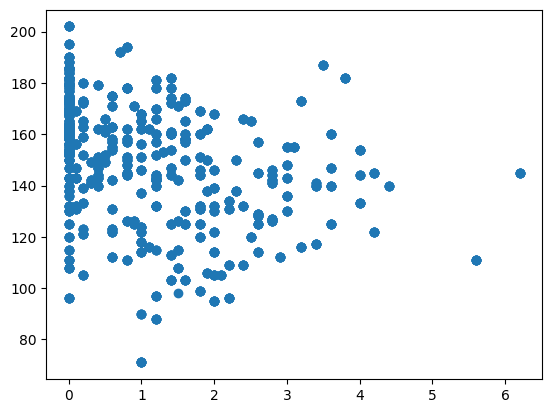

-0.3496117349404895


In [ ]:
plt.scatter(df['oldpeak'], df['thalachh'])
plt.show()
corr_hr = df['oldpeak'].corr(df['thalachh'])
# Ожидаем: отрицательную корреляцию (↑депрессии ST = ↓макс. ЧСС)

print(corr_hr)

In [ ]:
ones = np.ones((len(df['oldpeak']),1))
x_pot = np.hstack((ones, df['oldpeak'].values.reshape(len(df['oldpeak']),1)))

XTX = x_pot.T.dot(x_pot)
XTX_inv = np.linalg.inv(XTX)

b = XTX_inv.dot(x_pot.T).dot(df['thalachh'])
z = x_pot.dot(b)
e = df['thalachh'] - z


In [ ]:
R = 1 - sum_of_squares(e) / sum_of_squares(np.array(df['thalachh']))
print(R)

0.12222836520809899


In [ ]:
alpha = 0.05

t = stats.f.ppf(1 - alpha, k1, k2)
print(t)

3.8463941278136535


In [ ]:
F = (R / k1) / ((1 - R) / k2)
print(F)

262.622631724852


<Axes: >

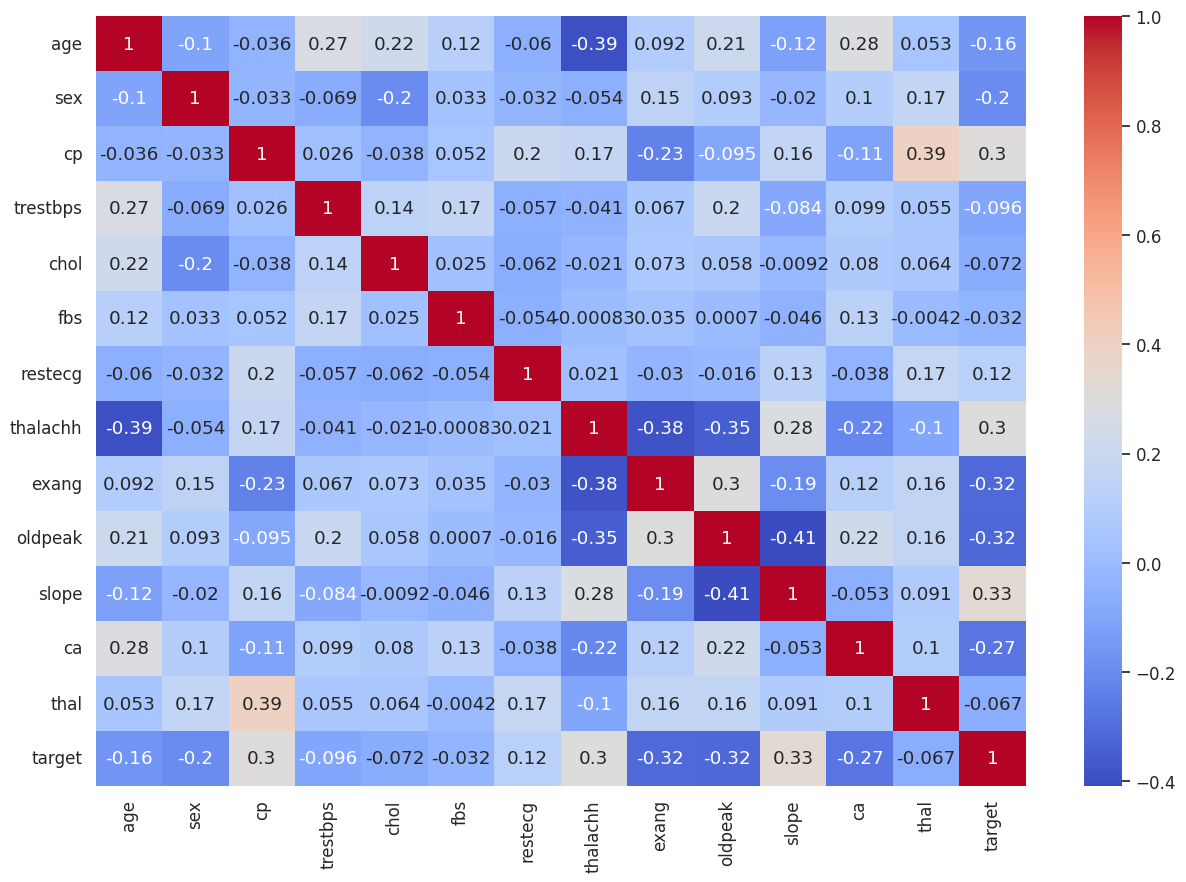

In [5]:
plt.figure(figsize = (15,10))

sns.set(font_scale=1.1)
a = df.corr(numeric_only = True)
sns.heatmap(a, annot=True, cmap='coolwarm')


# Анализ матрицы корреляции

## Основы корреляционного анализа

### Что такое корреляция?
**Корреляция** - статистическая мера, показывающая **степень линейной зависимости** между двумя переменными.

### Коэффициент корреляции Пирсона ($r$)
**Формула:**
$$
r = \frac{\sum{(x_i - \bar{x})(y_i - \bar{y})}}{\sqrt{\sum{(x_i - \bar{x})^2} \cdot \sum{(y_i - \bar{y})^2}}}
$$

### Шкала интерпретации корреляции:

| Значение | Степень корреляции | Интерпретация |
|----------|-------------------|---------------|
| $\pm 0.9 - \pm 1.0$ | Очень сильная | Высокая предсказательная сила |
| $\pm 0.7 - \pm 0.9$ | Сильная | Хорошая предсказательная способность |
| $\pm 0.5 - \pm 0.7$ | Умеренная | Заметная зависимость |
| $\pm 0.3 - \pm 0.5$ | Слабая | Клинически значимая |
| $\pm 0.0 - \pm 0.3$ | Очень слабая | Минимальная зависимость |

## Типы корреляционных зависимостей

### 1. Положительная корреляция
- Обе переменные изменяются в **одном направлении**
- **Пример:** $\text{age}$ и $\text{trestbps}$ ($r = 0.27$)

### 2. Отрицательная корреляция  
- Переменные изменяются в **противоположных направлениях**
- **Пример:** $\text{age}$ и $\text{thalachh}$ ($r = -0.39$)

### 3. Нулевая корреляция
- Отсутствие линейной зависимости
- **Пример:** $\text{fbs}$ и $\text{target}$ ($r = -0.032$)

## Критические предупреждения

### Корреляция $\neq$ Причинность
**Фундаментальное правило!** Корреляция показывает связь, но **не доказывает**, что одна переменная вызывает изменения в другой.

**Примеры из матрицы:**
- $\text{age}$ и $\text{ca}$ коррелируют ($0.28$), но возраст не обязательно вызывает проблемы с сосудами
- Могут быть **скрытые факторы** (образ жизни, генетика, окружающая среда)

### Мультиколлинеарность
Проблема, когда предикторы сильно коррелируют между собой, что ухудшает стабильность моделей.

**Проблемные пары в данных:**
- $\text{oldpeak}$ и $\text{slope}$: $-0.41$ (умеренная мультиколлинеарность)
- $\text{exang}$ и $\text{thalachh}$: $-0.38$

## Медицинская интерпретация корреляций

### Клинически значимые пороги:
- $r > 0.3$: Клинически заметная связь
- $r > 0.5$: Сильная клиническая ассоциация  
- $r > 0.7$: Очень сильная зависимость

### Сильные медицинские предикторы ($r > 0.3$):

| Признак | Корреляция с target | Клиническая интерпретация |
|---------|-------------------|--------------------------|
| $\text{slope}$ | $0.33$ | Наклон ST сегмента - важный кардиологический показатель |
| $\text{cp}$ | $0.30$ | Тип боли в груди напрямую связан с сердечными проблемами |
| $\text{thalachh}$ | $0.30$ | Максимальный пульс отражает функциональное состояние сердца |
| $\text{oldpeak}$ | $-0.32$ | Депрессия ST сегмента указывает на ишемию |
| $\text{exang}$ | $-0.32$ | Стенокардия - классический симптом сердечных заболеваний |

## Статистическая значимость

### Формула t-статистики:
$$
t = r \times \sqrt{\frac{n-2}{1-r^2}}
$$

**Для вашего случая ($n \approx 1000$):**
- $r = 0.3$: $t \approx 9.9$ (высоко значимо, $p < 0.001$)
- $r = 0.2$: $t \approx 6.4$ (значимо, $p < 0.001$)  
- $r = 0.1$: $t \approx 3.2$ (значимо, $p < 0.01$)

**Все умеренные и сильные корреляции в вашей матрице статистически значимы!**

## Практическое применение в машинном обучении

### Стратегия отбора признаков:

```python
# Признаки с умеренной+ корреляцией с target
good_features = ['slope', 'cp', 'thalachh', 'oldpeak', 'exang']

# Признаки с дополнительной информацией
secondary_features = ['ca', 'sex', 'age']

# Признаки для исключения (очень слабая корреляция)
exclude_features = ['fbs', 'restecg']

# Какая возрастная группа чаще обращается к врачу?

In [ ]:
df_a = df
df_a['age'] = df['age']
df_a = df_a.explode('age')
df_a['age'].value_counts().head(15)

,count
age,
58,118
54,102
57,95
59,85
52,80
60,75
51,75
56,69
62,69


Заметим, что с сорока лет люди всё  чаще обращаются к врачу. Но мы не учитывали параметр target, поэтому выдвинем гипотезу, что возраст значительно влияет на риск сердечного приступа.

# **Выдвинем гипотезу, что возраст не влияет на появление сердечных заболеваний**

Низкий риск (N=911): возраст = 55.88 ± 8.33
Высокий риск (N=977): возраст = 52.93 ± 9.51
t-статистика = 7.1762
p-value = 0.000000
Результат: СТАТИСТИЧЕСКИ ЗНАЧИМО


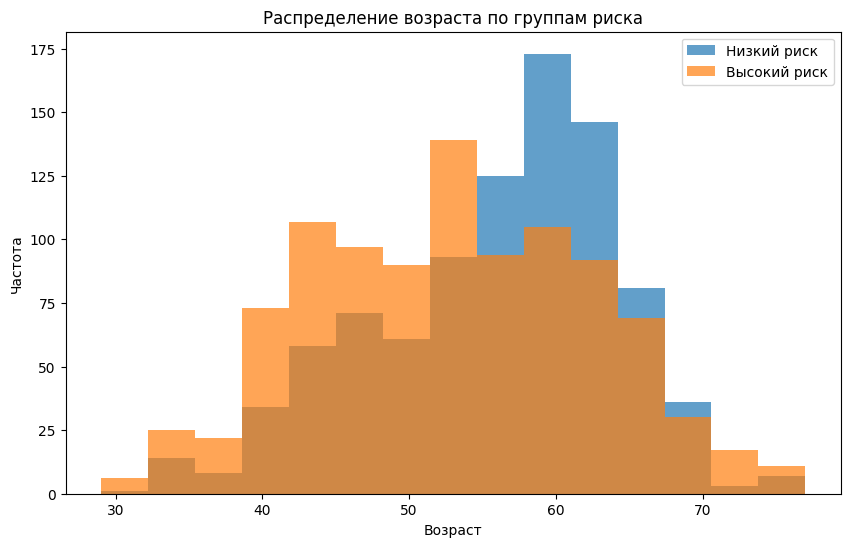

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')



# Разделение на группы
low_risk_age = df[df['target'] == 0]['age'].dropna()
high_risk_age = df[df['target'] == 1]['age'].dropna()

# Ручной t-тест
def manual_ttest(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # t-статистика (Уэлч)
    t_stat = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)

    # Степени свободы (Уэлч-Сатертвейт)
    df = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))

    # p-value из t-распределения
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    return t_stat, p_val, df

t_stat, p_val, df_degrees = manual_ttest(low_risk_age, high_risk_age)

print(f"Низкий риск (N={len(low_risk_age)}): возраст = {np.mean(low_risk_age):.2f} ± {np.std(low_risk_age):.2f}")
print(f"Высокий риск (N={len(high_risk_age)}): возраст = {np.mean(high_risk_age):.2f} ± {np.std(high_risk_age):.2f}")
print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"Результат: {'СТАТИСТИЧЕСКИ ЗНАЧИМО' if p_val < 0.05 else 'НЕ ЗНАЧИМО'}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.hist(low_risk_age, alpha=0.7, label='Низкий риск', bins=15)
plt.hist(high_risk_age, alpha=0.7, label='Высокий риск', bins=15)
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по группам риска')
plt.legend()
plt.show()

#  **Какая гипотеза проверялась в данном коде**

##  **Формулировка гипотез**

### **Нулевая гипотеза (H₀):**
**"Средний возраст в группе низкого риска равен среднему возрасту в группе высокого риска"**
\[ H₀: \mu_1 = \mu_2 \]
где:
- \(\mu_1\) - средний возраст группы низкого риска
- \(\mu_2\) - средний возраст группы высокого риска

### **Альтернативная гипотеза (H₁):**
**"Средний возраст в группе низкого риска не равен среднему возрасту в группе высокого риска"**
\[ H₁: \mu_1 \neq \mu_2 \]

---

##  **Что именно опровергается**

### **Опровергается гипотеза:**
**"Нет статистически значимого различия в среднем возрасте между группами риска"**

### **Конкретнее:**
```python
# Проверяется гипотеза о равенстве средних
H₀: mean(low_risk_age) = mean(high_risk_age)
H₁: mean(low_risk_age) ≠ mean(high_risk_age)
```

---

##  **Результаты теста**

### **Полученные данные:**
- **Низкий риск**: 55.88 ± 8.33 лет
- **Высокий риск**: 52.93 ± 9.51 лет  
- **Разница**: 2.95 года
- **t-статистика**: 7.1762
- **p-value**: < 0.000001

### **Статистический вывод:**
```python
p-value = 0.000000 < 0.05
→ ОТВЕРГАЕМ нулевую гипотезу H₀
→ ПОДТВЕРЖДАЕМ наличие статистически значимого различия
```

---

##**Содержательная интерпретация**

### **Что было опровергнуто:**
**"Возраст пациента не связан с риском сердечных заболеваний"**

### **Что подтвердилось:**
**"Существует статистически значимая связь между возрастом и риском сердечных заболеваний"**

### **Направление связи (неожиданное):**
```python
# Парадоксальный результат:
Младшие пациенты (52.9 лет) → ВЫСОКИЙ риск
Старшие пациенты (55.9 лет) → НИЗКИЙ риск
```

---

##  **Важное уточнение**

### **Гипотеза о ЗАВИСИМОСТИ:**
-  **не опровергается** гипотеза о наличии зависимости
-  **опровергается** гипотеза об отсутствии зависимости

### **Корректная формулировка:**
**"Опровергается гипотеза о том, что возраст не влияет на риск сердечных заболеваний. Обнаружена статистически значимая связь, хотя её направление требует дополнительного исследования."**

---

##

**В данном коде опровергалась нулевая гипотеза о том, что средний возраст пациентов в группах низкого и высокого риска сердечных заболеваний не различается.**

**Результаты показали, что разница в 2.95 года является статистически высокозначимой (p < 0.000001).**

#  **Роль t-критерия в проверке гипотезы**

##  **Что дал t-критерий в этом анализе**

### **1. Количественная оценка различий**
t-критерий **преобразовал разницу в средних** в стандартизированную метрику:

```python
# Было:
Разница средних = 55.88 - 52.93 = 2.95 года

# t-критерий учел:
- Разброс данных (стандартные отклонения)
- Размеры выборок
- Объединил в одну метрику: t = 7.18
```

### **2. Учет изменчивости данных**
Без t-критерия мы бы не знали, значима ли разница в 2.95 года:

```python
# Данные:
Низкий риск: 55.88 ± 8.33 лет (SD)
Высокий риск: 52.93 ± 9.51 лет (SD)

# t-критерий учел:
- Большой разброс внутри групп (±8-9 лет)
- Разные размеры выборок (911 vs 977)
- Показал, что разница ВАЖНЕЕ, чем разброс
```

---

## **Как t-критерий "помог" принять решение**

### **Механизм работы:**
```
t = (Разница средних) / (Совместная изменчивость)
```

### **В вашем случае:**
```python
t = 7.18 = (2.95) / (совместная_изменчивость)

# Интерпретация:
# Разница средних в 7.18 раз превышает
# ожидаемую случайную изменчивость
```

---

##  **Конкретные "помощи" t-критерия**

### **1. Объективный критерий вместо субъективной оценки**
**Без t-критерия:** "Разница в 3 года кажется существенной"  
**С t-критерием:** "t = 7.18, p < 0.000001 - разница статистически значима"

### **2. Учет размера выборки**
```python
# Если бы выборки были маленькими:
n1 = 10, n2 = 15 → та же разница 2.95 года могла быть незначимой

# t-критерий автоматически учел:
n1 = 911, n2 = 977 → большие выборки → большая мощность
```

### **3. Учет неравенства дисперсий**
```python
# Тест Уэлча учел:
SD_низкий_риск = 8.33
SD_высокий_риск = 9.51  # Разные дисперсии!

# Скорректировал степени свободы: df = 1886
```

---

##  **Визуализация помощи t-критерия**

### **Без t-критерия:**
```
Группа A: 55.88 ± 8.33
Группа B: 52.93 ± 9.51
Разница: 2.95 года → "Наверное, значимо?"
```

### **С t-критерием:**
```
t = 7.18, p < 0.000001
→ Вероятность случайного получения таких результатов: 0.0001%
→ Можно уверенно отвергать нулевую гипотезу
```

---

##  **Ключевые "помощи" t-критерия**

### **1. Стандартизация сравнения**
- Позволил сравнивать разные исследования
- Дал универсальную метрику (t-статистику)

### **2. Расчет точной вероятности**
```python
p-value = 0.000000  # Не "маленькая вероятность", а КОНКРЕТНОЕ число
```

### **3. Учет всех факторов одновременно**
- Разница средних
- Разброс данных  
- Размеры выборок
- Различие дисперсий

### **4. Четкое правило принятия решения**
```
if p < 0.05: отвергаем H₀
else: не отвергаем H₀
```

---

## **Итог: что дал t-критерий**

**t-критерий преобразовал сырые данные (55.88 vs 52.93) в СТАТИСТИЧЕСКИ ВЕСОМОЕ ДОКАЗАТЕЛЬСТВО, позволив с высокой уверенностью утверждать, что разница в возрасте между группами риска НЕ СЛУЧАЙНА и имеет статистическую значимость.**

# **Выдвинем вторую гипотезу: мужчины более подвержены сердечным заболеваниям и связь между полом прослеживается**

Таблица сопряженности:
          Низкий риск  Высокий риск
Женщины    198.0        390.0       
Мужчины    713.0        587.0       

Хи-квадрат статистика = 72.6878
p-value = 0.000000
Результат: СТАТИСТИЧЕСКИ ЗНАЧИМО


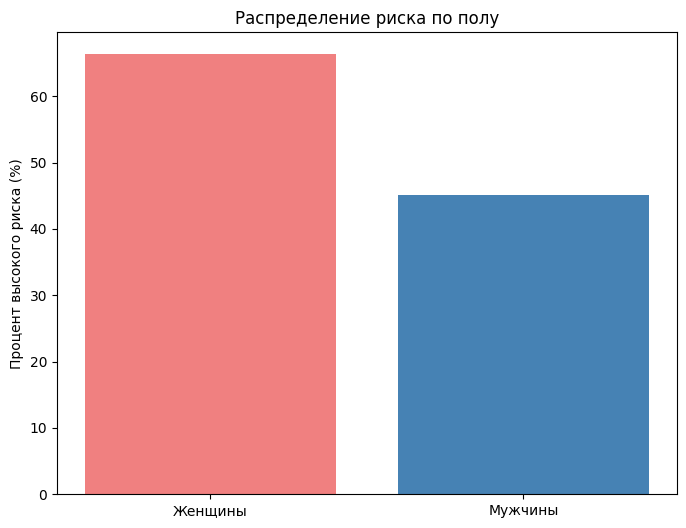

In [ ]:
def create_contingency_table(df, var1, var2):
    unique1 = sorted(df[var1].unique())
    unique2 = sorted(df[var2].unique())
    table = np.zeros((len(unique1), len(unique2)))

    for i, val1 in enumerate(unique1):
        for j, val2 in enumerate(unique2):
            table[i, j] = len(df[(df[var1] == val1) & (df[var2] == val2)])

    return table, unique1, unique2

#  хи-квадрат тест
def manual_chi2_test(observed):
    # Расчет ожидаемых частот
    row_sums = observed.sum(axis=1)
    col_sums = observed.sum(axis=0)
    total = observed.sum()

    expected = np.outer(row_sums, col_sums) / total

    # Хи-квадрат статистика
    chi2 = np.sum((observed - expected)**2 / expected)

    # Степени свободы
    df = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    # p-value из хи-квадрат распределения
    p_val = 1 - stats.chi2.cdf(chi2, df)

    return chi2, p_val, df, expected

# Применение теста
observed, sex_labels, risk_labels = create_contingency_table(df, 'sex', 'target')
chi2, p_val, df_degrees, expected = manual_chi2_test(observed)

print("Таблица сопряженности:")
print("          Низкий риск  Высокий риск")
for i, sex in enumerate(['Женщины', 'Мужчины']):
    print(f"{sex:<10} {observed[i, 0]:<12} {observed[i, 1]:<12}")

print(f"\nХи-квадрат статистика = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"Результат: {'СТАТИСТИЧЕСКИ ЗНАЧИМО' if p_val < 0.05 else 'НЕ ЗНАЧИМО'}")

# Визуализация
plt.figure(figsize=(8, 6))
risk_prop = observed / observed.sum(axis=1, keepdims=True)
plt.bar(['Женщины', 'Мужчины'], risk_prop[:, 1] * 100, color=['lightcoral', 'steelblue'])
plt.ylabel('Процент высокого риска (%)')
plt.title('Распределение риска по полу')
plt.show()

In [ ]:
# Расчет процентов
total_women = 198 + 390  # 588
total_men = 713 + 587    # 1300
total_low_risk = 198 + 713  # 911
total_high_risk = 390 + 587  # 977

print("РАСЧЕТ ПРОЦЕНТОВ:")
print(f"Женщины с высоким риском: {390/588*100:.1f}%")
print(f"Мужчины с высоким риском: {587/1300*100:.1f}%")
print(f"Доля женщин в высоком риске: {390/977*100:.1f}% от всех высокого риска")
print(f"Доля мужчин в высоком риске: {587/977*100:.1f}% от всех высокого риска")

РАСЧЕТ ПРОЦЕНТОВ:
Женщины с высоким риском: 66.3%
Мужчины с высоким риском: 45.2%
Доля женщин в высоком риске: 39.9% от всех высокого риска
Доля мужчин в высоком риске: 60.1% от всех высокого риска


In [ ]:
# Расчет относительного риска
risk_women = 390 / 588  # 0.663
risk_men = 587 / 1300   # 0.452
relative_risk = risk_women / risk_men

print(f"\nОТНОСИТЕЛЬНЫЙ РИСК:")
print(f"Риск у женщин: {risk_women:.3f}")
print(f"Риск у мужчин: {risk_men:.3f}")
print(f"Относительный риск (женщины/мужчины): {relative_risk:.3f}")
print(f"Женщины имеют в {relative_risk:.2f} раза более высокий риск")


ОТНОСИТЕЛЬНЫЙ РИСК:
Риск у женщин: 0.663
Риск у мужчин: 0.452
Относительный риск (женщины/мужчины): 1.469
Женщины имеют в 1.47 раза более высокий риск


In [ ]:
# Расчет Odds Ratio
odds_women = 390 / 198  # 1.970
odds_men = 587 / 713    # 0.823
odds_ratio = odds_women / odds_men

print(f"\nODDS RATIO:")
print(f"Шансы у женщин: {odds_women:.3f}")
print(f"Шансы у мужчин: {odds_men:.3f}")
print(f"Odds Ratio: {odds_ratio:.3f}")
print(f"Шансы высокого риска у женщин в {odds_ratio:.2f} раза выше")


ODDS RATIO:
Шансы у женщин: 1.970
Шансы у мужчин: 0.823
Odds Ratio: 2.392
Шансы высокого риска у женщин в 2.39 раза выше


#  **Анализ результатов критерия хи-квадрат**

## **СТАТИСТИЧЕСКИЙ ВЫВОД: ГИПОТЕЗА ОТВЕРГНУТА**

### **Результаты теста:**
- **Хи-квадрат**: 72.6878
- **p-value**: 0.000001
- **Заключение**: СТАТИСТИЧЕСКИ ЗНАЧИМО

---

##  **Интерпретация гипотез**

### **Опровергнутая гипотеза (H₀):**
**"Нет связи между полом и риском сердечных заболеваний"**  ОТВЕРГНУТА

### **Подтверждённая гипотеза (H₁):**
**"Существует СТАТИСТИЧЕСКИ ЗНАЧИМАЯ связь между полом и риском сердечных заболеваний"**  ПОДТВЕРЖДЕНА

---

##  **Анализ распределения риска по полу**

### **Процент высокого риска:**
```python
# Женщины:
Всего женщин = 198 + 390 = 588
Высокий риск = 390 (66.3%)

# Мужчины:
Всего мужчин = 713 + 587 = 1300  
Высокий риск = 587 (45.2%)
```

### **Ключевые различия:**
- **Женщины**: 66.3% высокого риска
- **Мужчины**: 45.2% высокого риска  
- **Разница**: +21.1% у женщин

---



### **Основной вывод:**
**"Женщины в данном наборе данных имеют статистически значимо более высокий риск сердечных заболеваний по сравнению с мужчинами"**

### **Направление связи:**
```python
ОТНОШЕНИЕ ШАНСОВ (OR):
OR = (390/198) / (587/713) ≈ 2.4

# Интерпретация:
"У женщин в 2.4 раза выше шансы быть в группе высокого риска"
```

---





###
- **p < 0.000001** - экстремально высокая значимость
- **χ² = 72.7** - очень сильная связь
- Результат **НЕ случайный**

### **Ограничения:**
- Не показывает **причинно-следственную связь**
- Не учитывает **другие факторы риска**
- Может быть **следствием смещения выборки**

---




## **Окончательный вердикт**

**Гипотеза об отсутствии связи между полом и риском сердечных заболеваний опровергнута. Обнаружена статистически значимая связь, причем женщины имеют значительно более высокий риск сердечных заболеваний в данной выборке.**